In [1]:
import xarray as xr
import rioxarray as rio
import matplotlib.pyplot as plt
import os
from glob import glob
import rasterio as ras
from pathlib import Path as pa
from multiprocessing import Pool
import multiprocessing

In [2]:
def process_file(file_path):
    try:
        ds = rio.open_rasterio(file_path)
        binary = xr.where(ds.isin([3,4,8,9,11,12]),2,1)
        # Preserve all attributes and metadata
        binary.attrs = ds.attrs.copy()  # Copy all attributes
        binary.name = 'crop_nonCrop'  # Optional: give it a new name
        
        # Preserve coordinates and dimensions
        # if not os.path.isdir(str(pa(file_path).parent.parent / f'binary_{pa(file_path).parent.name}')):
            # os.makedirs(str(pa(file_path).parent.parent / f'binary_{pa(file_path).parent.name}'))
        # out_path = str(pa(file_path).parent.parent / f'binary_{pa(file_path).parent.name}' / pa(file_path).name)
        out_path = f'/discover/nobackup/ejalilva/data/prithvi/datasets--ibm-nasa-geospatial--multi-temporal-crop-noncrop-classification/snapshots/04b439f179e52a7b144f69676210eecd30c39cfc/validation_chips/{pa(file_path).name}'
        binary = binary.assign_coords(ds.coords)
        binary.rio.to_raster(out_path, driver='GTiff', dtype='uint8', nodata=ds.rio.nodata)
        return f"Success: {file_path}"
    except Exception as e:
        return print(f'there was an error reading the file: {str(e)}')

In [14]:
def plot_bin(file_path):
    # Quick visualization
    ds = rio.open_rasterio(file_path)
    binary = xr.where(ds.isin([3,4,8,9,11,12]),2,1)
    # Preserve all attributes and metadata
    binary.attrs = ds.attrs.copy()  # Copy all attributes
    binary.name = 'crop_nonCrop'  # Optional: give it a new name
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
    ds.plot(ax=ax1, robust=True)
    ax1.set_title('Original')
    binary.plot(ax=ax2, cmap='binary')
    ax2.set_title('Binary (Crop/Non-crop)')

In [ ]:
if __name__ == "__main__":
   
    dataset_folder_path = '/discover/nobackup/ejalilva/data/prithvi/datasets--ibm-nasa-geospatial--multi-temporal-crop-classification/snapshots/04b439f179e52a7b144f69676210eecd30c39cfc/validation_chips/'
    files = glob(os.path.join(dataset_folder_path,'*.mask.tif'))
    n_workers = max(1, multiprocessing.cpu_count() - 1)
    print(f"Processing {len(files)} files with {n_workers} workers")
    
    with Pool(n_workers) as pool:
        results = pool.map(process_file, files)
    
    # Print results
    for result in results:
        print(result)
    plot_bin(files[0]) 

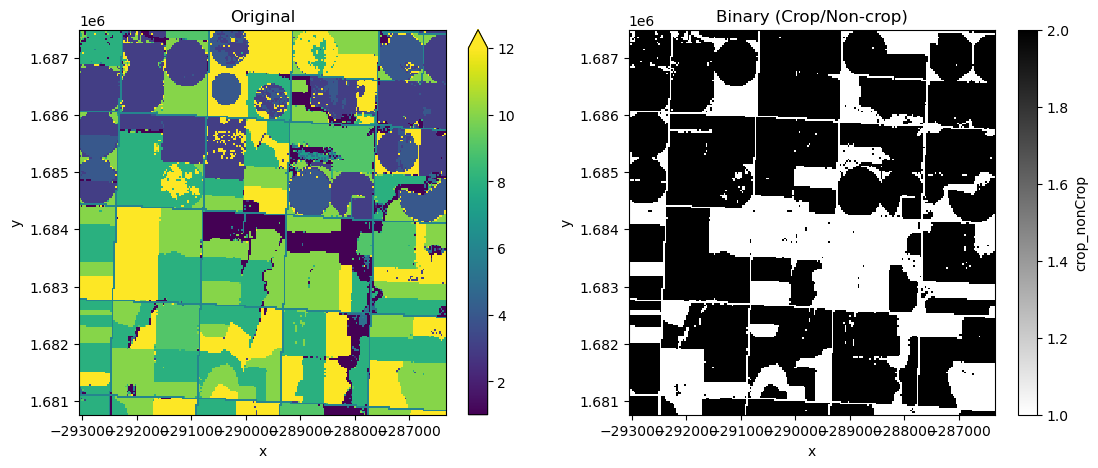

In [67]:
plot_bin(files[120])

In [5]:
dataset_folder_path = '/discover/nobackup/ejalilva/data/prithvi/datasets--ibm-nasa-geospatial--multi-temporal-crop-noncrop-classification/snapshots/04b439f179e52a7b144f69676210eecd30c39cfc/training_chips/'
files = glob(os.path.join(dataset_folder_path,'*mask.tif'))
len(files)

3083

In [6]:
rio.open_rasterio(files[0])

<xarray.DataArray (band: 1, y: 224, x: 224)> Size: 50kB
[50176 values with dtype=uint8]
Coordinates:
  * band         (band) int64 8B 1
  * x            (x) float64 2kB -5.753e+05 -5.752e+05 ... -5.686e+05 -5.686e+05
  * y            (y) float64 2kB 1.298e+06 1.298e+06 ... 1.291e+06 1.291e+06
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0
    long_name:      crop_nonCrop

In [ ]:
crop = 0
nonCrop = 0
for file in files:
    data = rio.open_rasterio(files[0])
    crop += data.where(data.isin([2])).count(dim=["x", "y"])
    nonCrop += data.where(data.isin([1])).count(dim=["x", "y"])
    total += crop+nonCrop

In [15]:
import numpy as np
class_counts = np.array([nonCrop, crop])  # Example counts
total_pixels = np.sum(class_counts)
class_weights = total_pixels / class_counts

In [16]:
class_weights

array([[2.47245491],
       [1.67913794]])